# Support Vector Machines

In [1]:
from mlscratch.svm import SVMHardMargin, SVMSoftMargin, SVM
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_classification
from sklearn.metrics import accuracy_score

Every model here gives each point a score, and the sign of that score is the predicted class. The decision boundary is where the score is 0, and the edges of the margin are where it is ±1.

This helper shades each side of the boundary, draws the boundary as a solid line and the margin edges as dashed lines.

In [2]:
def plot_decision_boundary(score, X, y):
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = score(grid).reshape(xx.shape)

    plt.contourf(xx, yy, zz, levels=[zz.min(), 0, zz.max()], colors=["#a6cee3", "#fb9a99"], alpha=0.5)
    plt.contour(xx, yy, zz, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

### Hard Margin
For data that a straight line can separate, we use the `SVMHardMargin` class. It finds the line that separates the two classes with the widest possible margin.

To start we initialise `X` and `y` feature and target datasets respectively. `make_blobs` labels the classes 0 and 1, but `SVMHardMargin` and `SVMSoftMargin` expect -1 and +1, so we convert them.

In [3]:
X, y = make_blobs(n_samples=100, centers=[(-2, -2), (2, 2)], cluster_std=1.0, random_state=0)
y = np.where(y == 1, 1, -1)

We then create an instance of `SVMHardMargin`, here called `hard_model`. It has no hyperparameters.

All the methods implemented in this library follow the standard `fit` and `predict` workflow. Since this is purely an example notebook, each model is trained on the whole dataset and predicts on the same dataset.

In [4]:
hard_model = SVMHardMargin()

In [5]:
hard_model.fit(X, y)

In [6]:
y_pred = hard_model.predict(X)
accuracy_score(y, y_pred)

1.0

`SVMHardMargin` has no `decision_function` method, so we pass its score `X @ w + b` to the helper directly. The points lying on the dashed lines are the support vectors: they alone decide where the boundary sits.

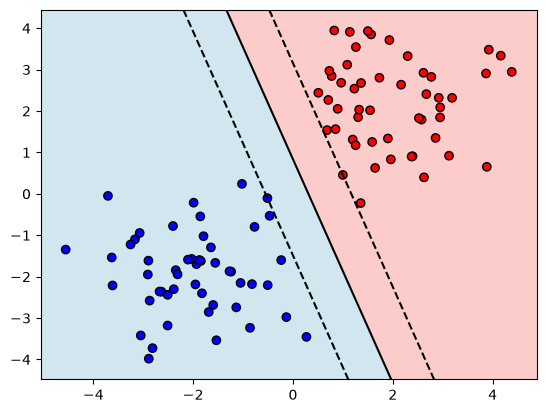

In [7]:
plot_decision_boundary(lambda grid: grid @ hard_model.w + hard_model.b, X, y)

### Soft Margin
When the classes overlap, no line separates them and `SVMHardMargin` fails with an error. `SVMSoftMargin` lets some points fall inside the margin, or on the wrong side of the boundary, at a cost set by the hyperparameter `C`. A large `C` makes those points expensive and gives a narrow margin; a small `C` tolerates more of them in exchange for a wider one. Here we keep the default `C=1.0`.

We use the same dataset as the logistic regression demo.

In [8]:
X, y = make_classification(
    n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=0,
)
y = np.where(y == 1, 1, -1)

In [9]:
soft_model = SVMSoftMargin(C=1.0)
soft_model.fit(X, y)

In [10]:
y_pred = soft_model.predict(X)
accuracy_score(y, y_pred)

0.96

Unlike the hard margin, some points now sit inside the margin and a few are on the wrong side of the boundary.

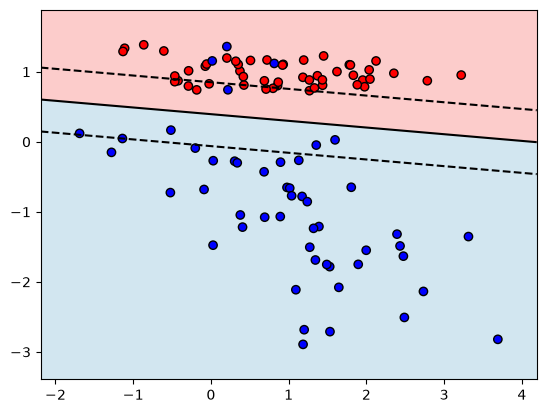

In [11]:
plot_decision_boundary(lambda grid: grid @ soft_model.w + soft_model.b, X, y)

### Kernel SVM
`SVM` solves the same soft-margin problem in its *dual* form, where the data only appear through dot products between pairs of points. Replacing that dot product with a *kernel* lets the boundary curve. `SVM` takes three hyperparameters: `kernel` (`"linear"` or `"rbf"`), `C` as above, and `gamma`, which sets how far each training point's influence reaches under the RBF kernel. A larger `gamma` means a shorter reach and a more flexible boundary.

Unlike the two classes above, `SVM` accepts any two labels, so the 0/1 labels from `make_circles` are passed in unchanged. The data are two rings, one inside the other, which no straight line can separate.

In [12]:
X, y = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=0)

With `kernel="linear"` the model can still only draw a straight line, so it does no better than guessing.

In [13]:
linear_model = SVM(kernel="linear")
linear_model.fit(X, y)

In [14]:
y_pred = linear_model.predict(X)
accuracy_score(y, y_pred)

0.455

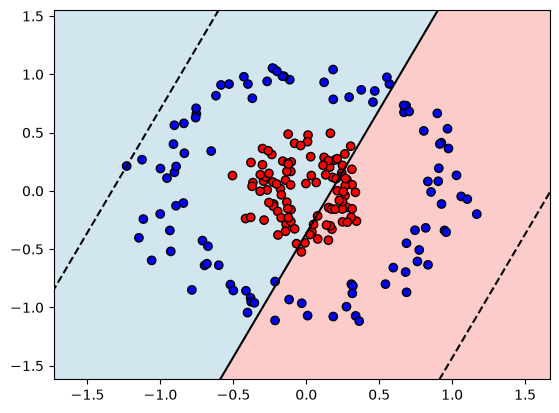

In [15]:
plot_decision_boundary(linear_model.decision_function, X, y)

With `kernel="rbf"` the boundary can curve around the inner ring. `SVM` has a `decision_function` method, so it can be passed to the helper as it is.

In [16]:
rbf_model = SVM(kernel="rbf", C=1.0, gamma=1.0)
rbf_model.fit(X, y)

In [17]:
y_pred = rbf_model.predict(X)
accuracy_score(y, y_pred)

1.0

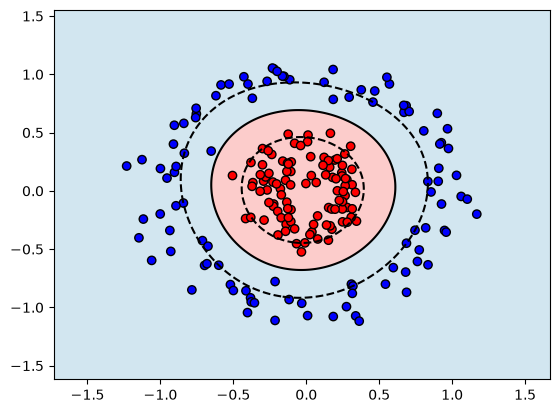

In [18]:
plot_decision_boundary(rbf_model.decision_function, X, y)